# Import the necessary libraries

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as sm
from datetime import date 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error as mae
from sklearn import tree
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, Lasso, Ridge, ElasticNetCV, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn import linear_model
from sklearn import metrics
import seaborn as sns
from numpy import arange
from sklearn.model_selection import RepeatedKFold

In [19]:
#  Set the amount of columns so that I can see all of the columns
pd.set_option('display.max_columns', 200)

In [20]:
#  Read in the dataset
df = pd.read_csv('C:/Users/chadc/Downloads/DATA SCIENCE MAIN COURSE/Capstone Project/features_final1.csv')

In [21]:
#  Call the head method on the dataframe to make sure that things look okay
df.head()

,fnd_PConc,neigh_NridgHt,mas_vnr_type_Stone,neigh_NoRidge,extsecond_VinylSd,extfirst_VinylSd,ctrl_air_Y,zoning_RL,roof_style_Hip,gar_type_BuiltIn,neigh_StoneBr,roof_style_Gable,gar_type_None,zoning_RM,fnd_CBlock,gar_type_Detchd,mas_vnr_type_None,age_of_prop,SalePrice,OverallQual,GrLivArea,ExterQual,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,GarageFinish,TotRmsAbvGrd,FireplaceQu,YearRemodAdd,HeatingQC,BsmtFinSF1,BsmtExposure,LotFrontage,WoodDeckSF,2ndFlrSF,OpenPorchSF,BsmtFinType1,HalfBath,GarageQual,LotArea,GarageCond,Electrical,PavedDrive,BsmtFullBath,BsmtUnfSF,BsmtCond
0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,5,208500,7,1710,3,548,856,856,4,2,2,8,0,2003,4,706,1,65.0,0,854,61,6,1,3,8450,3,4,2,1,150,3
1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,1,31,181500,6,1262,2,460,1262,1262,4,2,2,6,3,1976,4,978,4,80.0,298,0,0,5,0,3,9600,3,4,2,0,284,3
2,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,7,223500,7,1786,3,608,920,920,4,2,2,6,3,2002,4,486,2,68.0,0,866,42,6,1,3,11250,3,4,2,1,434,3
3,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,1,1,91,140000,7,1717,2,642,756,961,3,1,1,7,4,1970,3,216,1,60.0,0,756,35,5,0,3,9550,3,4,2,1,540,4
4,1,0,0,1,1,1,1,1,0,0,0,1,0,0,0,0,0,8,250000,8,2198,3,836,1145,1145,4,2,2,9,3,2000,4,655,3,84.0,192,1053,84,6,1,3,14260,3,4,2,1,490,3


In [22]:
# Double check the shape of the dataframe
df.shape

(1460, 48)

In [23]:
#  Drop the 2 'SalePrice' outliers for houses that exceed $700,000
df[df['SalePrice'] > 700000]
df.drop([691, 1182], inplace=True)

In [24]:
#  Create a variable for the dataframe and a variable for the target
X1 = df.drop(['SalePrice'], axis=1)
y1 = df['SalePrice']

In [25]:
#  Create a numpy array from the X and Y variables
X = X1.values
y = y1.values

In [26]:
#  Create a train/test split of the data with a 80/20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .20, random_state=42)

In [27]:
#  Check the shape of the dataframe again to ensure that the train set contains approximately 80% of the 
#  entire values
X_train.shape

(1166, 47)

In [28]:
#  Check the shape of the dataframe again to ensure that the train set contains approximately 20% of the 
#  entire values
X_test.shape

(292, 47)

In [29]:
#  Check the shape of the dataframe again to ensure that the test set contains approximately 80% of the 
#  entire values
y_train.shape

(1166,)

In [30]:
#  Check the shape of the dataframe again to ensure that the train set contains approximately 20% of the 
#  entire values
y_test.shape

(292,)

In [31]:
# Scale the data so that it has zero mean and unit variance:
#  (Mean value of 0 and 1 standard deviation)

#  ss = StandardScaler()
#  Compute the mean and std to be used for later scaling.  Apply the Scaler to the X variable
# ss.fit(X_train) 
# ss.fit(X_test)

# using mean and std of training data for transforming the data for test set
# Perform standardization by centering and scaling
# X_train = ss.transform(X_train)
# X_test = ss.transform(X_test)
# john = pd.DataFrame(X_train)
# john
# james = pd.DataFrame(X_test)
# james
# X = pd.concat([john, james], ignore_index=True, axis=0)

# 1.  Dummy Regression

In [32]:
#  Insantiate a DummyRegressor to obtain a baseline and compare our model against
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size = .20, random_state=42)
dummy_regr = DummyRegressor(strategy = 'median') #Look up mean/median

#  Fit the regressor on the training data
dummy_regr.fit(X_train1, y_train1)

# Predict on the test data
y_pred1 = dummy_regr.predict(X_test1)

# Apply cross validation across the training set
dummy_scores = cross_val_score(dummy_regr, X_train1, y_train1, cv=10)

print('Linear Regression R2 Training Score', dummy_regr.score(X_train1, y_train1))
tr1 = dummy_regr.score(X_train1, y_train1)
print('Linear Regression R2 Test Score', dummy_regr.score(X_test1, y_test1))
print('Average 10 Fold Cross Validation R2 Score:', dummy_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
print('The Root Mean Squared Error (RMSE) is: ', rmse1)

# MEAN SQUARED ERROR
mse1 = mean_squared_error(y_test1, y_pred1)
print('The Mean Squared Error (MSE) is: ', mse1)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k1 = mae(y_pred1, y_test1)
print('The Mean Absolute Error is (MAE): ', k1)

# R-Squared
r1 = round(sm.r2_score(y_test1, y_pred1), 6)
print("R Squared (R^2) score is: ", r1)

Linear Regression R2 Training Score -0.04947841575544287
Linear Regression R2 Test Score -0.052564642958031316
Average 10 Fold Cross Validation R2 Score: -0.05524261298130928
The Root Mean Squared Error (RMSE) is:  75540.05297391159
The Mean Squared Error (MSE) is:  5706299603.30137
The Mean Absolute Error is (MAE):  56921.760273972606
R Squared (R^2) score is:  -0.052565


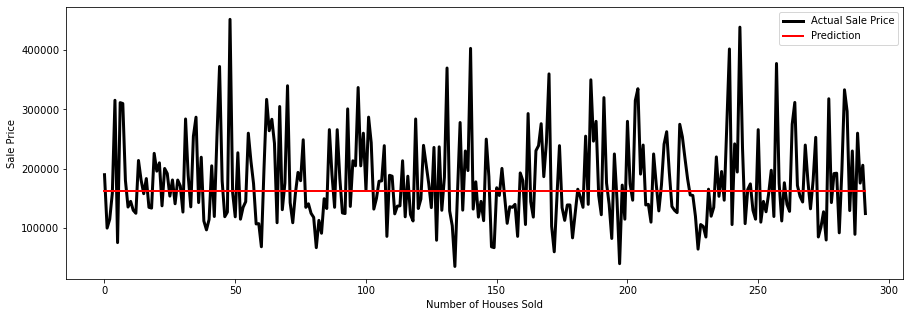

In [33]:
# Plot the prediction along with the test data for the target variable
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test1, color='k', lw=3)
ax.plot(y_pred1, color='r', lw=2)
plt.xlabel('Number of Houses Sold')
plt.ylabel('Sale Price')
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

# 2.  Linear Regression

In [34]:
#  Split the data into train and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size = .20, random_state=42)

# Instantiate a Linear Regressor
lr = LinearRegression()

#  Fit to the training data
lr.fit(X_train2, y_train2)

#  Predict the target on the test data
y_pred2 = lr.predict(X_test2)

# Cross Validate the test data
lr_scores = cross_val_score(lr, X_train2, y_train2, cv=10)

print('Linear Regression R2 Training Score', lr.score(X_train2, y_train2))
tr2 = lr.score(X_train2, y_train2)
print('Linear Regression R2 Test Score', lr.score(X_test2, y_test2))
print('Average 10 Fold Cross Validation R2 Score:', lr_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
print('The Root Mean Squared Error (RMSE) is: ', rmse2)

# MEAN SQUARED ERROR
mse2 = mean_squared_error(y_test2, y_pred2)
print('The Mean Squared Error (MSE) is: ', mse2)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k2 = mae(y_pred2, y_test2)
print('The Mean Absolute Error is (MAE): ', k2)

# R-Squared
r2 = round(sm.r2_score(y_test2, y_pred2), 6)
print("R Squared (R^2) score is: ", r2)

Linear Regression R2 Training Score 0.83500321548728
Linear Regression R2 Test Score 0.8547901265575163
Average 10 Fold Cross Validation R2 Score: 0.7956515245156209
The Root Mean Squared Error (RMSE) is:  28057.629094636886
The Mean Squared Error (MSE) is:  787230550.4122143
The Mean Absolute Error is (MAE):  20580.98521872777
R Squared (R^2) score is:  0.85479


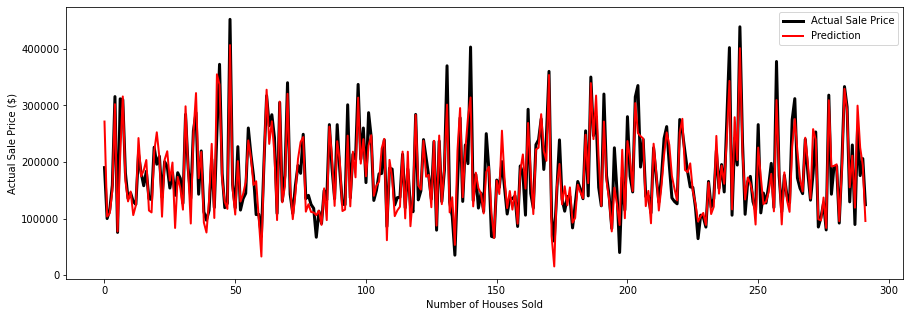

In [35]:
# Plot the prediction along with the test data for the target variable

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test2, color='k', lw=3)
ax.plot(y_pred2, color='r', lw=2)
plt.xlabel('Number of Houses Sold')
plt.ylabel('Actual Sale Price ($)')
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

In [36]:
#  Create a DataFrame to see how far from the actual sale price the predicted sale price is

that2 = list(y_pred2)
this2 = list(y_test2)
both2 = pd.DataFrame({'Actual Sale Price ($)':this2, 'Predicted Sale Price ($)':that2})
both2.head()

,Actual Sale Price ($),Predicted Sale Price ($)
0,190000,271384.232608
1,100000,103504.396702
2,115000,109322.290386
3,159000,149430.428563
4,315500,302084.813306


Text(27.0, 0.5, 'Predicted Sale Price ($)')

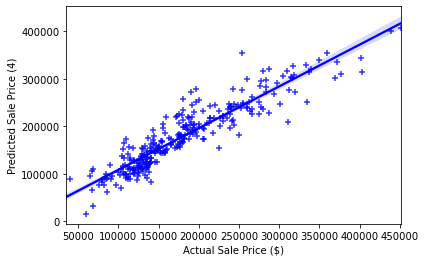

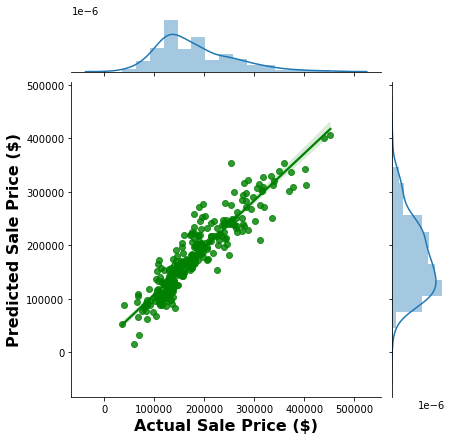

In [37]:
#  Create a regression plot for the Actual Sale Price against the Predicted Sale Price


ax = sns.regplot(x=this2, y=that2, marker="+", color="b")
ax.set(xlabel="Actual Sale Price ($)", ylabel = 'Predicted Sale Price (4)')
g = sns.jointplot(x='Actual Sale Price ($)', y='Predicted Sale Price ($)', data = both2, kind='reg',
                  joint_kws={'color':'green'})

g.set_axis_labels('x', 'y', fontsize=16)

# Set labels 
g.ax_joint.set_xlabel('Actual Sale Price ($)', fontweight='bold')
g.ax_joint.set_ylabel('Predicted Sale Price ($)', fontweight='bold')

In [38]:
#  Sort the values of the highest coefficients (Most important features) to the lowest (least important features)
lr_coef_series = pd.Series(lr.coef_, index=X1.columns).sort_values(ascending=False)
lr_coef_series

neigh_StoneBr         51864.299047
neigh_NridgHt         45742.752558
neigh_NoRidge         42986.801684
gar_type_None         19833.881244
extsecond_VinylSd     15216.400420
OverallQual           12561.258633
ExterQual             11759.167758
ctrl_air_Y            10541.135918
GarageQual             8923.289540
HalfBath               8154.875371
BsmtQual               7909.122419
gar_type_BuiltIn       6179.999290
BsmtExposure           5800.838680
TotRmsAbvGrd           5310.375963
mas_vnr_type_None      4949.231314
roof_style_Hip         4705.745503
BsmtFullBath           4628.865382
PavedDrive             4242.525431
FullBath               4183.156744
mas_vnr_type_Stone     3615.319453
FireplaceQu            2735.511476
GarageFinish           2208.087643
BsmtFinType1           1725.454723
HeatingQC              1336.630289
gar_type_Detchd         460.278880
fnd_PConc               450.544681
YearRemodAdd            170.108622
age_of_prop             114.339236
GarageArea          

In [39]:
#  Create a series in order to make a visualization of the most important features

lr_coef_features = pd.Series(lr.coef_, index=X1.columns).sort_values(ascending=True)
unimp_feat2 = lr_coef_features[lr_coef_features == 0].sort_index().index
new_feat2 = [i for i in lr_coef_features.index if i not in 
            list(lr_coef_features[lr_coef_features == 0].index)]

Text(0.5, 0, 'Features')

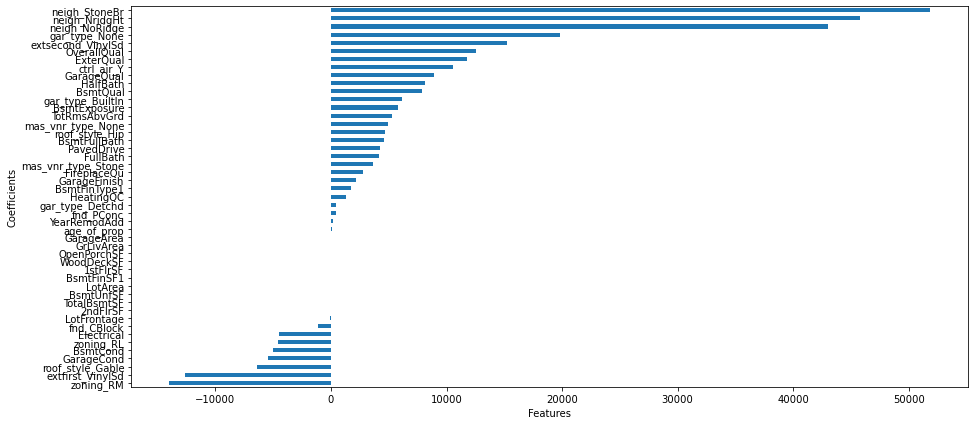

In [40]:
#  Create a bar plot with the coefficients ranging from the most important to the least important

lr_coef_features[new_feat2].plot(kind = 'barh', figsize=(15,7))
plt.ylabel('Coefficients')
plt.xlabel('Features')

In [41]:
#  Check to see how many features affect 'SalePrice'

len(new_feat2)

47

In [42]:
#  Check to see how many features do not affect 'SalePrice'

len(unimp_feat2)

0

# 3.  Ridge Regression

In [43]:
#  Split the data into training and testing sets
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size = .20, random_state=42)

#Instantiate the Ridge Regressor
ridge = Ridge(alpha=.3, normalize=True) ####

# Fit the regressor to the training set
ridge.fit(X_train3, y_train3)

# Predict on the test set
y_pred3 = ridge.predict(X_test3)

#  Cross validate the training #
ridge_scores = cross_val_score(ridge, X_train3, y_train3, cv=10)

print('Linear Regression R2 Training Score', ridge.score(X_train3, y_train3))
print('Linear Regression R2 Test Score', ridge.score(X_test3, y_test3))
print('Average 10 Fold Cross Validation R2 Score:', ridge_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse3 = np.sqrt(mean_squared_error(y_test3, y_pred3))
print('The Root Mean Squared Error (RMSE) is: ', rmse3)

# MEAN SQUARED ERROR
mse3 = mean_squared_error(y_test3, y_pred3)
print('The Mean Sqaured Error (MSE) is: ', mse3)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k3 = mae(y_pred3, y_test3)
print('The Mean Absolute Error is (MAE): ', k3)

# R-Squared
r3 = round(sm.r2_score(y_test3, y_pred3), 4)
print("R Squared (R^2) score is: ", r3)



Linear Regression R2 Training Score 0.8266641497925091
Linear Regression R2 Test Score 0.8638236415183009
Average 10 Fold Cross Validation R2 Score: 0.8048583646404277
The Root Mean Squared Error (RMSE) is:  27170.883138418078
The Mean Sqaured Error (MSE) is:  738256890.5215718
The Mean Absolute Error is (MAE):  19787.737663377033
R Squared (R^2) score is:  0.8638


#### Hyperparameter Tuning

In [44]:
# prepare a range of alpha values to test
alphas = np.array([1,0.1,0.01,0.001,0.0001,0])
# create and fit a ridge regression model, testing each alpha
model1 = Ridge()
cv3 = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)
grid = GridSearchCV(estimator=model1, param_grid=dict(alpha=alphas), cv=cv3)
grid.fit(X_train3, y_train3)
print(grid)
# summarize the results of the grid search
print('Best R2 score', grid.best_score_)
print('Best Alpha', grid.best_estimator_.alpha)

GridSearchCV(cv=RepeatedKFold(n_repeats=10, n_splits=10, random_state=42),
             estimator=Ridge(),
             param_grid={'alpha': array([1.e+00, 1.e-01, 1.e-02, 1.e-03, 1.e-04, 0.e+00])})
Best R2 score 0.7783187733510496
Best Alpha 1.0


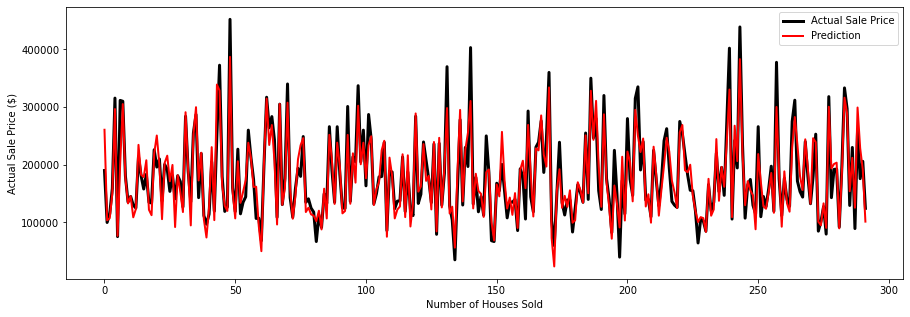

In [45]:
#  Plot the actual saleprice against the prediction
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test3, color='k', lw=3)
ax.plot(y_pred3, color='r', lw=2)
plt.xlabel('Number of Houses Sold')
plt.ylabel('Actual Sale Price ($)')
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

In [46]:
#  Create a dataframe to see how far the predictions are from the actual sale price

that3 = list(y_pred3)
this3 = list(y_test3)
both3 = pd.DataFrame({'Actual Sale Price ($)':this3, 'Predicted Sale Price ($)':that3})
both3.head()

,Actual Sale Price ($),Predicted Sale Price ($)
0,190000,260643.314506
1,100000,103814.248487
2,115000,107461.650015
3,159000,150506.025276
4,315500,296575.106187


Text(27.0, 0.5, 'Predicted Sale Price ($)')

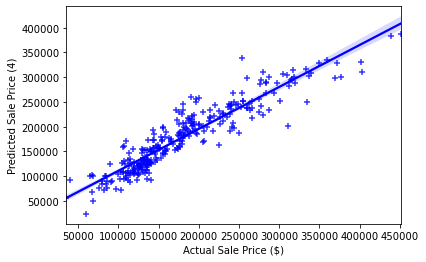

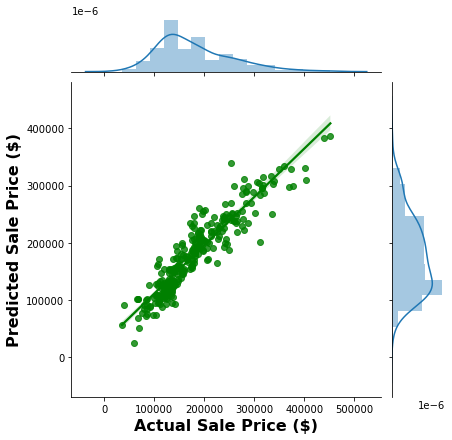

In [47]:
#  Plot a regression line of actual Sale Price and the Predicted Sale Price to see how well 
#  the regression line fits to the data

ax = sns.regplot(x=this3, y=that3, marker="+", color="b")
ax.set(xlabel="Actual Sale Price ($)", ylabel = 'Predicted Sale Price (4)')
g = sns.jointplot(x='Actual Sale Price ($)', y='Predicted Sale Price ($)', data = both3, kind='reg',
                  joint_kws={'color':'green'})

g.set_axis_labels('x', 'y', fontsize=16)

# Set labels
g.ax_joint.set_xlabel('Actual Sale Price ($)', fontweight='bold')
g.ax_joint.set_ylabel('Predicted Sale Price ($)', fontweight='bold')

In [48]:
#  Display the coefficients from the most important to the least important
ridge_coef_series = pd.Series(ridge.coef_, index=X1.columns).sort_values(ascending=False)
ridge_coef_series

neigh_StoneBr         42413.452301
neigh_NridgHt         35524.636518
neigh_NoRidge         31413.217417
ExterQual             11848.710543
OverallQual            8514.008434
ctrl_air_Y             6131.022386
HalfBath               6091.297869
roof_style_Hip         5613.320041
mas_vnr_type_Stone     5571.897445
FullBath               5268.737682
BsmtQual               4998.084083
BsmtExposure           4886.195762
gar_type_BuiltIn       4814.378918
BsmtFullBath           4212.783008
TotRmsAbvGrd           4117.378323
gar_type_None          3800.225257
FireplaceQu            3111.027777
fnd_PConc              2438.599275
PavedDrive             2246.338493
GarageFinish           2244.483565
HeatingQC              1779.051713
mas_vnr_type_None      1612.107103
GarageQual             1507.570144
extsecond_VinylSd      1316.104956
BsmtFinType1           1268.033844
zoning_RL               978.051644
YearRemodAdd            177.446592
GarageArea               33.464078
OpenPorchSF         

In [49]:
#  Separate the important features from the unimportant features based on the coefficients
ridge_coef_features = pd.Series(ridge.coef_, index=X1.columns).sort_values(ascending=True)
unimp_feat3 = ridge_coef_features[ridge_coef_features == 0].sort_index().index
new_feat3 = [i for i in ridge_coef_features.index if i not in 
            list(ridge_coef_features[ridge_coef_features == 0].index)]

Text(0.5, 0, 'Features')

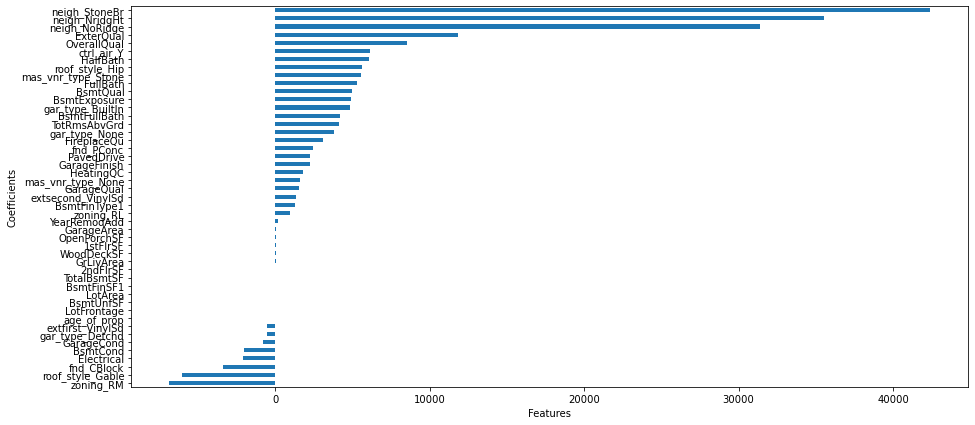

In [50]:
# Create a visualization of the coefficients
ridge_coef_features[new_feat3].plot(kind = 'barh', figsize=(15,7))
plt.ylabel('Coefficients')
plt.xlabel('Features')

In [51]:
# Find the number of the important features
len(new_feat3)

47

In [52]:
# Find the number of unimportant features
len(unimp_feat3)

0

# 4.  Bayesian Ridge Regression

In [53]:
#  Create a training set and a test set

X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size = .20, random_state=42)

# Instantiate the regressor
bayes = linear_model.BayesianRidge()

# Fit the data to the training set
bayes.fit(X_train4, y_train4)

#  Predict on the test set
y_pred4 = bayes.predict(X_test4)

#  Cross validate the training set
bayes_scores = cross_val_score(bayes, X_train4, y_train4, cv=10)

print('Linear Regression R2 Training Score', bayes.score(X_train4, y_train4))
print('Linear Regression R2 Test Score', bayes.score(X_test4, y_test4))
print('Average 10 Fold Cross Validation R2 Score:', bayes_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse4 = np.sqrt(mean_squared_error(y_test4, y_pred4))
print('The Root Mean Squared Error (RMSE) is: ', rmse4)

# MEAN SQUARED ERROR
mse4 = mean_squared_error(y_test4, y_pred4)
print('The Mean Sqaured Error (MSE) is: ', mse4)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k4 = mae(y_pred4, y_test4)
print('The Mean Absolute Error is (MAE): ', k4)

# R-Squared
r4 = round(sm.r2_score(y_test4, y_pred4), 4)
print("R Squared (R^2) score is: ", r4)


Linear Regression R2 Training Score 0.831699026651702
Linear Regression R2 Test Score 0.8558240780888188
Average 10 Fold Cross Validation R2 Score: 0.7928107810304662
The Root Mean Squared Error (RMSE) is:  27957.559954646113
The Mean Sqaured Error (MSE) is:  781625158.617632
The Mean Absolute Error is (MAE):  20762.5563608186
R Squared (R^2) score is:  0.8558


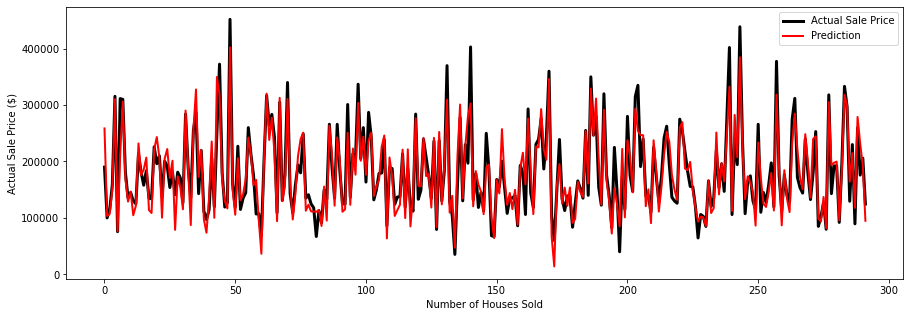

In [54]:
#  Plot the Actual sale price against the Predicted sale price
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test4, color='k', lw=3)
ax.plot(y_pred4, color='r', lw=2)
plt.xlabel('Number of Houses Sold')
plt.ylabel('Actual Sale Price ($)')
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

In [55]:
# Create a dataframe to compare the actual sale price to the predicted sale price
that4 = list(y_pred4)
this4 = list(y_test4)
both4 = pd.DataFrame({'Actual Sale Price ($)':this4, 'Predicted Sale Price ($)':that4})
both4.head()

,Actual Sale Price ($),Predicted Sale Price ($)
0,190000,258576.386083
1,100000,103344.194921
2,115000,107060.364023
3,159000,150958.394791
4,315500,310534.837961


Text(27.0, 0.5, 'Predicted Sale Price ($)')

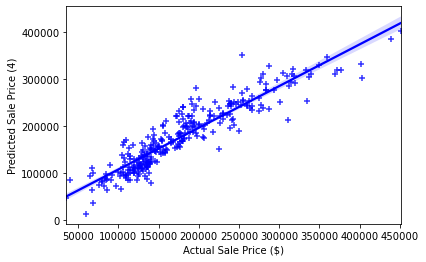

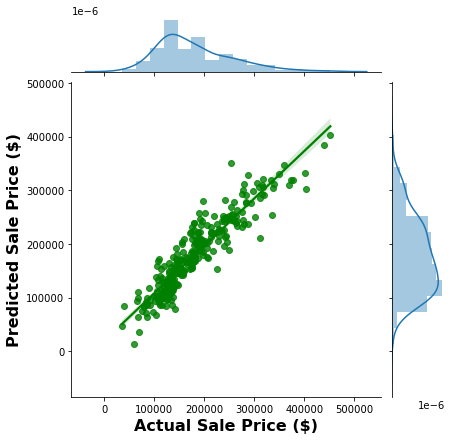

In [56]:
#  Create a regression plot to see how well the regression line fits the data

ax = sns.regplot(x=this4, y=that4, marker="+", color="b")
ax.set(xlabel="Actual Sale Price ($)", ylabel = 'Predicted Sale Price (4)')
g = sns.jointplot(x='Actual Sale Price ($)', y='Predicted Sale Price ($)', data = both4, kind='reg',
                  joint_kws={'color':'green'})

g.set_axis_labels('x', 'y', fontsize=16)

# Set labels via the axes objects
g.ax_joint.set_xlabel('Actual Sale Price ($)', fontweight='bold')
g.ax_joint.set_ylabel('Predicted Sale Price ($)', fontweight='bold')

In [57]:
#  Display the coefficients and their values from highest to lowest
bayes_coef_series = pd.Series(bayes.coef_, index=X1.columns).sort_values(ascending=False)
bayes_coef_series

neigh_NridgHt         31578.141643
neigh_StoneBr         27611.261458
neigh_NoRidge         25455.696277
OverallQual           13321.420059
ExterQual             12874.815833
BsmtQual               7871.153992
HalfBath               6859.504670
ctrl_air_Y             6678.367989
gar_type_None          5694.231560
BsmtExposure           5610.959131
gar_type_BuiltIn       5542.583050
roof_style_Hip         5270.606696
TotRmsAbvGrd           5011.296534
mas_vnr_type_None      4468.835578
BsmtFullBath           4177.116670
GarageQual             3917.446767
mas_vnr_type_Stone     3803.582289
extsecond_VinylSd      3462.734478
PavedDrive             3423.013476
FireplaceQu            3001.625766
FullBath               2715.445730
GarageFinish           1981.144635
fnd_PConc              1927.186486
BsmtFinType1           1828.059218
HeatingQC              1552.380403
zoning_RL               716.519105
YearRemodAdd            170.088866
gar_type_Detchd          86.726907
age_of_prop         

In [58]:
# Separate the important features from the unimportant features

bayes_coef_features = pd.Series(bayes.coef_, index=X1.columns).sort_values(ascending=True)
unimp_feat4 = bayes_coef_features[bayes_coef_features == 0].sort_index().index
new_feat4 = [i for i in bayes_coef_features.index if i not in 
            list(bayes_coef_features[bayes_coef_features == 0].index)]

Text(0.5, 0, 'Features')

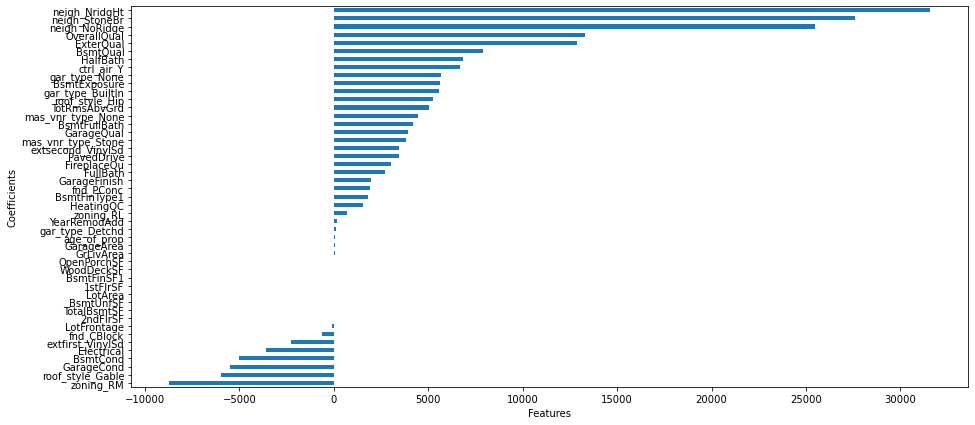

In [59]:
#  Create a visualization of the coefficient values
bayes_coef_features[new_feat4].plot(kind = 'barh', figsize=(15,7))
plt.ylabel('Coefficients')
plt.xlabel('Features')

In [60]:
#  Find the number of the important features
len(new_feat4)

47

In [61]:

# Find the number of the unimportant features
len(unimp_feat4)

0

# 5.  Lasso Regression

In [62]:
# Split the data into training and test sets

X_train5, X_test5, y_train5, y_test5 = train_test_split(X, y, test_size = .20, random_state=42)

#  Instantiate the regressor
lasso = Lasso(alpha=40, normalize=True)

#  Fit the regressor to the training data
lasso.fit(X_train5, y_train5)

# Predict on the test data
y_pred5 = lasso.predict(X_test5)

# Cross validate the training data
lasso_scores = cross_val_score(lasso, X_train5, y_train5, cv=10)

print('Linear Regression R2 Training Score', lasso.score(X_train5, y_train5))
print('Linear Regression R2 Test Score', lasso.score(X_test5, y_test5))
print('Average 10 Fold Cross Validation R2 Score:', lasso_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse5 = np.sqrt(mean_squared_error(y_test5, y_pred5))
print('The Root Mean Squared Error (RMSE) is: ', rmse5)

# MEAN SQUARED ERROR
mse5 = mean_squared_error(y_test5, y_pred5)
print('The Mean Sqaured Error (MSE) is: ', mse5)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k5 = mae(y_pred5, y_test5)
print('The Mean Absolute Error is (MAE): ', k5)

# R-Squared
r5 = round(sm.r2_score(y_test5, y_pred5), 4)
print("R Squared (R^2) score is: ", r5)



Linear Regression R2 Training Score 0.8275648730124354
Linear Regression R2 Test Score 0.8656762121904104
Average 10 Fold Cross Validation R2 Score: 0.8009368358359046
The Root Mean Squared Error (RMSE) is:  26985.43115726321
The Mean Sqaured Error (MSE) is:  728213494.7433921
The Mean Absolute Error is (MAE):  19768.169274686436
R Squared (R^2) score is:  0.8657


#### Hyperparameter Tuning

In [65]:
lasso_reg = Lasso()
params_Lasso = {'alpha': [1, 0.1,0.01,0.001,0.0001,0]}
Lasso_GS = GridSearchCV(lasso_reg, param_grid=params_Lasso, scoring='r2', cv=10,  n_jobs=-1)
Lasso_GS.fit(X_train5,y_train5)
print(Lasso_GS.best_params_)
print(Lasso_GS.best_score_)

{'alpha': 1}
0.7956645835670272


C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 555224335544.799, tolerance: 697621872.2806097
  model = cd_fast.enet_coordinate_descent(


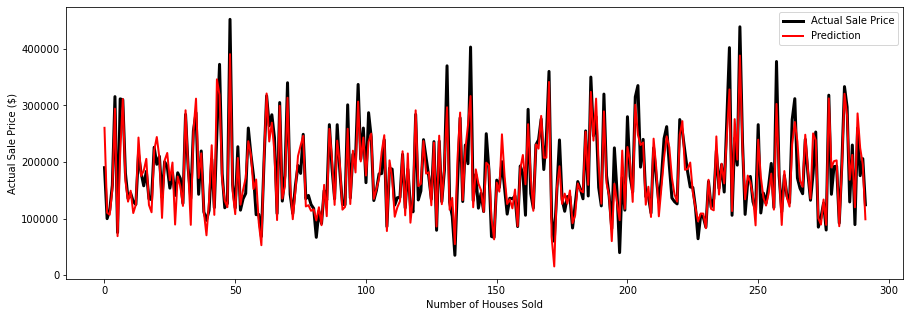

In [64]:
#  Plot the Actual sale price against the Predicted sale price
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test5, color='k', lw=3)
ax.plot(y_pred5, color='r', lw=2)
plt.xlabel('Number of Houses Sold')
plt.ylabel('Actual Sale Price ($)')
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

In [46]:
# Create a dataframe to compare the actual sale price to the predicted sale price
that5 = list(y_pred5)
this5 = list(y_test5)
both5 = pd.DataFrame({'Actual Sale Price ($)':this5, 'Predicted Sale Price ($)':that5})
both5.head()

,Actual Sale Price ($),Predicted Sale Price ($)
0,190000,260381.915513
1,100000,110390.780758
2,115000,106888.565567
3,159000,152030.816799
4,315500,294241.914107


Text(27.0, 0.5, 'Predicted Sale Price ($)')

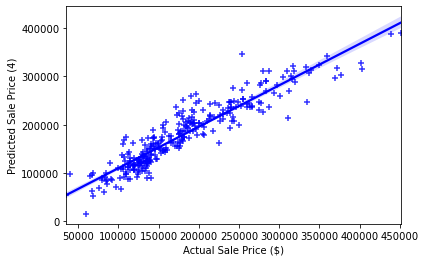

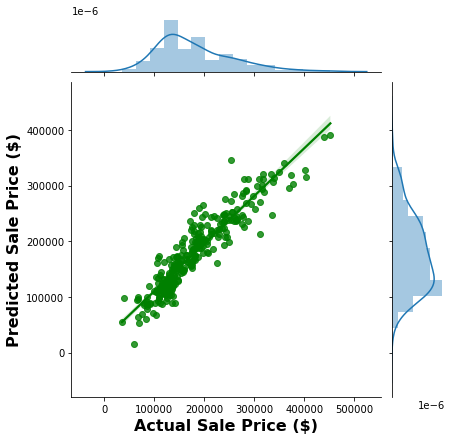

In [47]:
#  Create a regression plot to see how well the regression line fits the data

ax = sns.regplot(x=this5, y=that5, marker="+", color="b")

ax.set(xlabel="Actual Sale Price ($)", ylabel = 'Predicted Sale Price (4)')
g = sns.jointplot(x='Actual Sale Price ($)', y='Predicted Sale Price ($)', data = both5, kind='reg',
                  joint_kws={'color':'green'})

g.set_axis_labels('x', 'y', fontsize=16)

# Set labels
g.ax_joint.set_xlabel('Actual Sale Price ($)', fontweight='bold')
g.ax_joint.set_ylabel('Predicted Sale Price ($)', fontweight='bold')

In [48]:
#  Display the coefficients and their values from highest to lowest
lasso_coef_series = pd.Series(lasso.coef_, index=X1.columns).sort_values(ascending=False)
lasso_coef_series

neigh_StoneBr         42450.396250
neigh_NridgHt         40735.162016
neigh_NoRidge         31009.929721
ExterQual             13443.412364
OverallQual           13024.293245
BsmtExposure           4985.396145
BsmtQual               4314.343371
BsmtFullBath           4150.634440
TotRmsAbvGrd           3969.522769
HalfBath               2864.424995
roof_style_Hip         2678.825100
FireplaceQu            2676.911253
fnd_PConc              1710.646172
GarageFinish           1485.809674
BsmtFinType1           1163.102015
HeatingQC               980.140752
gar_type_BuiltIn        732.039126
FullBath                691.075671
ctrl_air_Y              460.823326
YearRemodAdd            190.321182
GarageArea               37.250780
GrLivArea                25.135312
1stFlrSF                 11.481777
OpenPorchSF               9.155073
WoodDeckSF                8.893372
BsmtFinSF1                3.177075
LotArea                   0.398391
BsmtUnfSF                -0.000000
PavedDrive          

In [49]:
# Separate the important features from the unimportant features
lasso_coef_features = pd.Series(lasso.coef_, index=X1.columns).sort_values(ascending=True)
unimp_feat5 = lasso_coef_features[lasso_coef_features == 0].sort_index().index
new_feat5 = [i for i in lasso_coef_features.index if i not in 
            list(lasso_coef_features[lasso_coef_features == 0].index)]

Text(0.5, 0, 'Features')

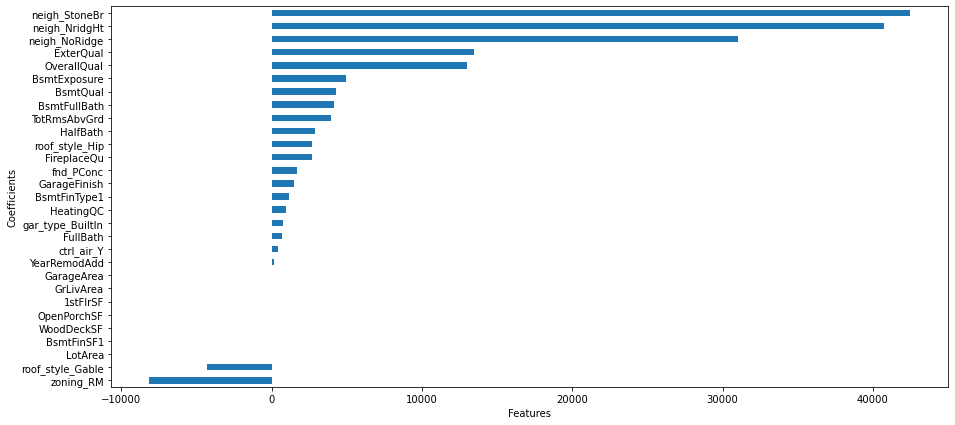

In [50]:
#  Create a visualization of the coefficient values
lasso_coef_features[new_feat5].plot(kind='barh', figsize=(15,7))
plt.ylabel('Coefficients')
plt.xlabel('Features')

In [51]:
#Find the number of the important features
len(new_feat5)

29

In [52]:
#Find the number of the unimportant features
len(unimp_feat5)

18

# 6.  Elastic Net Regression

In [53]:
# Split the data into training and test sets
X_train6, X_test6, y_train6, y_test6 = train_test_split(X, y, test_size = .20, random_state=42)

#  Instantiate the regressor
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Fit the regressor to the training data
elastic.fit(X_train6, y_train6)

# Predict on the test data
y_pred6 = elastic.predict(X_test6)

# Cross validate the training data
elastic_scores = cross_val_score(elastic, X_train6, y_train6, cv=3)
print('Linear Regression R2 Training Score', elastic.score(X_train6, y_train6))
print('Linear Regression R2 Test Score', elastic.score(X_test6, y_test6))
print('Average 10 Fold Cross Validation R2 Score:', elastic_scores.mean())


# ROOT MEAN SQUARED ERROR (RMSE)
rmse6 = np.sqrt(mean_squared_error(y_test6, y_pred6))
print('The Root Mean Squared Error (RMSE) is: ', rmse6)

# MEAN SQUARED ERROR
mse6 = mean_squared_error(y_test6, y_pred6)
print('The Mean Squared Error (MSE) is: ', mse6)

# MEAN ABSOLUTE ERROR OVER THE TEST SET (MAE)
k6 = mae(y_pred6, y_test6)
print('The Mean Absolute Error is (MAE): ', k6)

# R-Squared
r6 = round(sm.r2_score(y_test6, y_pred6), 6)
print("R Squared (R^2) score is: ", r6)


Linear Regression R2 Training Score 0.7998393371770838
Linear Regression R2 Test Score 0.8499868108408061
Average 10 Fold Cross Validation R2 Score: 0.7372308939819829
The Root Mean Squared Error (RMSE) is:  28517.905023646894
The Mean Squared Error (MSE) is:  813270906.9377447
The Mean Absolute Error is (MAE):  21507.39972725825
R Squared (R^2) score is:  0.849987


C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 739435793319.0839, tolerance: 697621872.2806097
  model = cd_fast.enet_coordinate_descent(
C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 337634751917.9362, tolerance: 469131947.63964397
  model = cd_fast.enet_coordinate_descent(
C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 565996017601.3337, tolerance: 475700234.4128938
  model = cd_fast.enet_coordinate_descent(
C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarni

#### Hyperparameter Tuning

In [25]:
# define model
model6 = ElasticNet()
# define model evaluation method
cv6 = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# define grid
grid6 = dict()
grid6['alpha'] = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0]
grid6['l1_ratio'] = arange(0, 1, 0.01)
# define search
search6 = GridSearchCV(model6, grid6, scoring='r2', cv=cv6, n_jobs=-1)
# perform the search
results6 = search6.fit(X_train6, y_train6)
# summarize
print('R2: %.3f' % results6.best_score_)
print('Best alpha and l1_ratio: %s' % results6.best_params_)

R2: 0.774
Best alpha and l1_ratio: {'alpha': 0.01, 'l1_ratio': 0.77}


C:\Users\chadc\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 585256165769.3939, tolerance: 697621872.2806097
  model = cd_fast.enet_coordinate_descent(


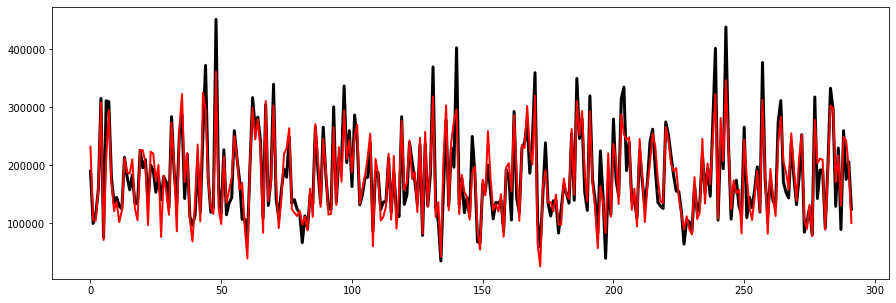

In [54]:
#  Plot the Actual sale price against the Predicted sale price
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test6, color='k', lw=3)
ax.plot(y_pred6, color='r', lw=2)
plt.legend(['Actual Sale Price', 'Prediction'])
plt.show()

In [62]:
# Create a dataframe to compare the actual sale price to the predicted sale pricethat6 = list(y_pred6)
that6 = list(y_pred6)
this6 = list(y_test6) 
both6 = pd.DataFrame({'Actual Sale Price ($)':this6, 'Predicted Sale Price ($)':that6})
both6.head()

,Actual Sale Price ($),Predicted Sale Price ($)
0,190000,232468.601578
1,100000,105790.992842
2,115000,104844.333340
3,159000,161017.070827
4,315500,308379.471702


In [ ]:
#  Create a regression plot to see how well the regression line fits the data
ax = sns.regplot(x=this6, y=that6, marker="+", color="b")
ax.set(xlabel="Actual Sale Price ($)", ylabel = 'Predicted Sale Price (4)')
g = sns.jointplot(x='Actual Sale Price ($)', y='Predicted Sale Price ($)', data = both6, kind='reg',
                  joint_kws={'color':'green'})

g.set_axis_labels('x', 'y', fontsize=16)

# Set labels 
g.ax_joint.set_xlabel('Actual Sale Price ($)', fontweight='bold')
g.ax_joint.set_ylabel('Predicted Sale Price ($)', fontweight='bold')

In [56]:
#  Display the coefficients and their values from highest to lowest
elastic_coef_series = pd.Series(elastic.coef_, index=X1.columns).sort_values(ascending=False)
elastic_coef_series

OverallQual           10029.424189
ExterQual              5153.688630
FireplaceQu            3998.577871
BsmtExposure           3875.784540
neigh_NridgHt          3551.686236
BsmtQual               3455.014353
TotRmsAbvGrd           2983.250410
roof_style_Hip         2488.617915
HeatingQC              1765.367021
BsmtFinType1           1755.079877
GarageFinish           1547.702578
neigh_StoneBr          1489.589411
zoning_RL              1436.741723
fnd_PConc              1356.399000
mas_vnr_type_Stone     1336.667202
neigh_NoRidge          1280.023742
BsmtFullBath           1170.053434
HalfBath               1113.995506
gar_type_BuiltIn        988.666721
gar_type_None           513.132616
YearRemodAdd            317.655249
extsecond_VinylSd       281.660286
PavedDrive              203.068622
extfirst_VinylSd        200.998762
mas_vnr_type_None       155.234044
ctrl_air_Y               97.695160
GarageArea               56.201666
GrLivArea                49.947741
OpenPorchSF         

In [75]:
# Separate the important features from the unimportant features
elastic_coef_features = pd.Series(elastic.coef_, index=X1.columns).sort_values(ascending=True)
unimp_feat6 = elastic_coef_features[elastic_coef_features == 0].sort_index().index
new_feat6 = [i for i in elastic_coef_features.index if i not in 
            list(elastic_coef_features[elastic_coef_features == 0].index)]

Text(0.5, 0, 'Features')

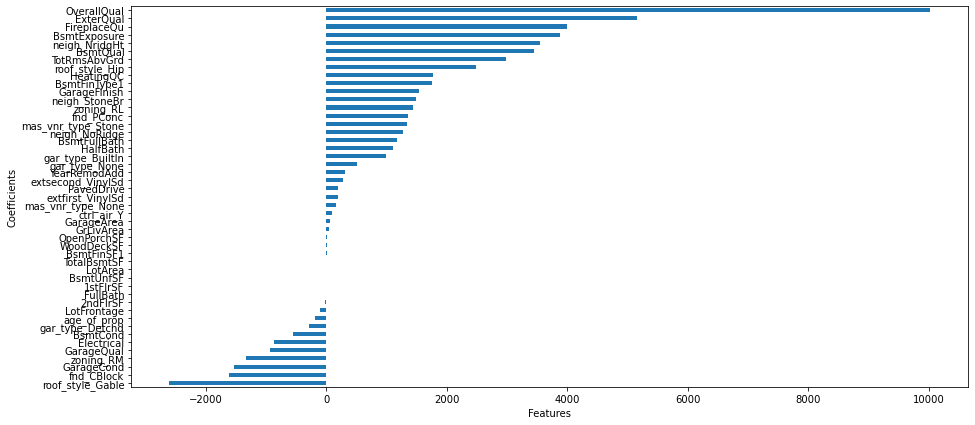

In [76]:
#  Create a visualization of the coefficient values
elastic_coef_features[new_feat6].plot(kind='barh', figsize=(15,7))
plt.ylabel('Coefficients')
plt.xlabel('Features')

In [59]:
#Find the number of the important features
len(new_feat6)

47

In [60]:
#Find the number of the unimportant features
len(unimp_feat6)

0

In [70]:
#  Create a table to compare the actual price against the predicted price across all models

tts = pd.DataFrame({'Actual Sale Price':this2, 'Linear Regression':that2, 'Ridge Regression':that3, 'Bayes Regression':that4, 
                    'Lasso Regression':that5,
                   'Elastic Net':that6})
tts.head()

,Actual Sale Price,Linear Regression,Ridge Regression,Bayes Regression,Lasso Regression,Elastic Net
0,190000,271384.232608,260643.314506,258576.386083,260381.915513,232468.601578
1,100000,103504.396702,103814.248487,103344.194921,110390.780758,105790.992842
2,115000,109322.290386,107461.650015,107060.364023,106888.565567,104844.333340
3,159000,149430.428563,150506.025276,150958.394791,152030.816799,161017.070827
4,315500,302084.813306,296575.106187,310534.837961,294241.914107,308379.471702


In [64]:
# Model metric comparison

test = ['Dummy Regression', 'Linear Regression', 'Ridge Regression', 'Bayesian Regression', 'Lasso Regression', 'Elastic Net Regression']
RMSEs = [rmse1, rmse2, rmse3, rmse4, rmse5, rmse6]
R2s = [r1, r2, r3, r4, r5, r6]
MAEs = [k1, k2, k3, k4, k5, k6]
MSEs = [mse1, mse2, mse3, mse4, mse5, mse6]
TNFCV = [dummy_scores.mean(), lr_scores.mean(), ridge_scores.mean(), bayes_scores.mean(), lasso_scores.mean(), elastic_scores.mean()]

rsts = pd.DataFrame({'Model':test, 'MSE':MSEs, 'MAE':MAEs, 'RMSE':RMSEs, '10 Fold Cross Validation': TNFCV, ' Test R2':R2s})
rsts['MSE']=(np.floor(rsts['MSE']*10000)/10000).map('{:,.4f}'.format)

rsts.head(6)

,Model,MSE,MAE,RMSE,10 Fold Cross Validation,Test R2
0,Dummy Regression,"5,706,299,603.3013",56921.760274,75540.052974,-0.055243,-0.052565
1,Linear Regression,"787,230,550.4122",20580.985219,28057.629095,0.795652,0.854790
2,Ridge Regression,"738,256,890.5215",19787.737663,27170.883138,0.804858,0.863800
3,Bayesian Regression,"781,625,158.6176",20762.556361,27957.559955,0.792811,0.855800
4,Lasso Regression,"728,213,494.7433",19768.169275,26985.431157,0.800937,0.865700
5,Elastic Net Regression,"813,270,906.9377",21507.399727,28517.905024,0.737231,0.849987


In [82]:
#  Print the top 5 features for each model
top_coefs = pd.DataFrame({'Linear Regression':lr_coef_features.index[42:].sort_values(ascending=False), 
                          'Ridge Regression':ridge_coef_features.index[42:].sort_values(ascending=False), 
                          'Bayes Regression':bayes_coef_features.index[42:].sort_values(ascending=False), 
                          'Lasso Regreession':lasso_coef_features.index[42:].sort_values(ascending=False), 
                          'Elastic Net Regression':elastic_coef_features.index[42:].sort_values(ascending=False)}) 
top_coefs

,Linear Regression,Ridge Regression,Bayes Regression,Lasso Regreession,Elastic Net Regression
0,neigh_StoneBr,neigh_StoneBr,neigh_StoneBr,neigh_StoneBr,neigh_NridgHt
1,neigh_NridgHt,neigh_NridgHt,neigh_NridgHt,neigh_NridgHt,OverallQual
2,neigh_NoRidge,neigh_NoRidge,neigh_NoRidge,neigh_NoRidge,FireplaceQu
3,gar_type_None,OverallQual,OverallQual,OverallQual,ExterQual
4,extsecond_VinylSd,ExterQual,ExterQual,ExterQual,BsmtExposure


In [78]:
from numpy import arange
from pandas import read_csv
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
# load the dataset
# define model
model3 = Ridge()
# define model evaluation method
cv3 = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)
# define grid
grid3 = dict()
grid3['alpha'] = arange(0, 1, 0.01)
# define search
search3 = GridSearchCV(model3, grid3, scoring='r2', cv=cv3, n_jobs=10)
# perform the search
results3 = search3.fit(X_train3, y_train3)
# summarize
print('Alpha: %.3f' % results3.best_score_)
print('Config: %s' % results3.best_params_)

Alpha: 0.778
Config: {'alpha': 0.99}


In [ ]:
##classification report??

In [93]:
# Grid Search for Algorithm Tuning
import numpy as np
from sklearn import datasets
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=.2, random_state = 42)
# prepare a range of alpha values to test
alphas = np.array([1,0.1,0.01,0.001,0.0001,0])
# create and fit a ridge regression model, testing each alpha
model3 = Ridge()
grid3 = GridSearchCV(estimator=model3, param_grid=dict(alpha=alphas))
grid3.fit(X_train3, y_train3)
print(grid3)
# summarize the results of the grid search
print(grid3.best_score_)
print(grid3.best_estimator_.alpha)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': array([1.e+00, 1.e-01, 1.e-02, 1.e-03, 1.e-04, 0.e+00])})
0.7876976048704369
1.0
